# 10 – Interaktív Pipeline Orchestrátor

Egyetlen felületen látható, hogyan hat a Nut-detekció pontosságára:
- **Preprocessing** (CLAHE, Blur, Normalizálás)
- **Profiling mód** (Linear / Power / Max-pooling / Sobel-X / Auto)
- **ROI stratégia** (MediaPipe / Legacy Geo / Extended Nut Margin)
- **Detection paraméterek** (Nut szélességhatárok, Peak threshold)

Minden logika `src/` modulokból importálódik. A notebook csak GUI + vizualizáció.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import contextlib
%matplotlib inline

In [2]:
import pandas as pd
from pathlib import Path

import src.config as _src_config
from src.config import CFG, PREPROCESSING_CONFIG, PATHS
from src.fretboard import run_v14_pipeline, IntensityFretDetector, GeometricFretDetector
from src.preprocess import ImagePreprocessor
from src.viz import draw_master_dashboard, debug_nut_detection, PipelineVisualizer, draw_finger_mapping, finger_mapping_table_rows
from src.viz import draw_master_dashboard, debug_nut_detection, PipelineVisualizer, draw_finger_mapping, finger_mapping_table_rows
from src.viz_diagnostics import create_full_pipeline_audit
from src.logic import map_fingers_to_frets

# ── Manifest betöltése + képlista összeállítása ───────────────────────────────
manifest = pd.read_csv(PATHS["manifest"])

# Validációs képek osztályonként 3-3 db (gyors iterációhoz)
sample_rows = (
    manifest[manifest["split"] == "val"]
    .groupby("class")
    .head(3)
    .reset_index(drop=True)
)
# Training képekből is vegyünk, ha kevés a val
train_sample = (
    manifest[manifest["split"] == "train"]
    .groupby("class")
    .head(2)
    .reset_index(drop=True)
)
all_samples = pd.concat([sample_rows, train_sample], ignore_index=True)

image_options = {
    f"[{r['class']}] {r['filename']}  ({r['split']})": r.to_dict()
    for _, r in all_samples.iterrows()
}
print(f"Betöltött képek száma: {len(image_options)}")

Betöltött képek száma: 40


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIG UTILITIES
#
#  config_patch() – kontextuskezelő (pipeline futása alatt ideiglenes override)
#  update_config() – Architecture Switcher (globálisan patcheli a CFG-t + widgetek)
# ═══════════════════════════════════════════════════════════════════════════════

@contextlib.contextmanager
def config_patch(**overrides):
    """Ideiglenesen felülírja a CFG / PREPROCESSING_CONFIG értékeit.

    A context manager kilépésekor visszaállítja az eredeti értékeket.
    Thread-safe Jupyter futtatás esetén (egy cella fut egyszerre).
    """
    cfg_backup  = {}
    prep_backup = {}
    for k, v in overrides.items():
        if k in _src_config.CFG:
            cfg_backup[k]  = _src_config.CFG[k]
            _src_config.CFG[k] = v
        elif k in _src_config.PREPROCESSING_CONFIG:
            prep_backup[k] = _src_config.PREPROCESSING_CONFIG[k]
            _src_config.PREPROCESSING_CONFIG[k] = v
    try:
        yield
    finally:
        _src_config.CFG.update(cfg_backup)
        _src_config.PREPROCESSING_CONFIG.update(prep_backup)


def update_config(overrides: dict):
    """Architecture Switcher – globálisan felülírja a CFG / widget értékeket.

    Speciális kulcs: ``'PROFILING_MODE'`` → a widget értékét is frissíti.

    Példa::

        update_config({'PROFILING_MODE': 'sobel'})
        update_config({'PROFILING_MODE': 'max', 'clahe_enabled': False})
        update_config({'nut_min_width_px': 4.0, 'nut_max_width_px': 25.0})
    """
    profiling_mode = overrides.pop('PROFILING_MODE', None)
    if profiling_mode is not None:
        profiling_mode = str(profiling_mode).lower()
        valid = ['linear', 'power', 'max', 'sobel', 'auto']
        if profiling_mode not in valid:
            print(f"[update_config] WARN: ismeretlen mód {profiling_mode!r}, valid: {valid}")
        else:
            if 'w_profile_mode' in globals():
                w_profile_mode.value = profiling_mode
            print(f"[update_config] PROFILING_MODE → {profiling_mode}")

    for k, v in overrides.items():
        if k in _src_config.CFG:
            _src_config.CFG[k] = v
            print(f"[update_config] CFG[{k!r}] = {v!r}")
        elif k in _src_config.PREPROCESSING_CONFIG:
            _src_config.PREPROCESSING_CONFIG[k] = v
            print(f"[update_config] PREPROCESSING_CONFIG[{k!r}] = {v!r}")
            if k == 'clahe_enabled' and 'w_clahe' in globals():
                w_clahe.value = bool(v)
            elif k == 'blur_enabled' and 'w_blur' in globals():
                w_blur.value = bool(v)
        else:
            print(f"[update_config] WARN: {k!r} nem ismert CFG kulcs")

In [4]:
from scipy.ndimage import gaussian_filter1d
import ipywidgets as widgets
import logging

if 'out_display' not in globals():
    out_display = widgets.Output()


# ─────────────────────────────────────────────────────────────────────────────
#  High-res figure rendering for inline notebook output
# ─────────────────────────────────────────────────────────────────────────────

_HIGH_RES_FIGURE_RC = {
    "figure.dpi": 180,
    "savefig.dpi": 220,
}


@contextlib.contextmanager
def high_res_figure_context():
    """Temporarily render notebook figures at a higher pixel density."""
    with plt.rc_context(_HIGH_RES_FIGURE_RC):
        yield


# ─────────────────────────────────────────────────────────────────────────────
#  Debug: 4-profil összehasonlítás (09-es notebook stílusában)
# ─────────────────────────────────────────────────────────────────────────────

def _draw_profile_comparison(canon_bgr: np.ndarray, result: dict = None):
    """4-profil összehasonlítás: Linear / Power / Max-pooling / Sobel-X."""
    gray  = cv2.cvtColor(canon_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    sigma = 1.5

    def _ns(p):
        p = gaussian_filter1d(p, sigma)
        mx = float(p.max())
        return p / mx if mx > 1e-6 else p

    profiles = {
        "Lineáris":    _ns(gray.mean(axis=0)),
        "Power (x²)": _ns(((gray / 255.0) ** 2).mean(axis=0)),
        "Max-pooling": _ns(gray.max(axis=0)),
        "Sobel-X":     _ns(np.abs(cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)).sum(axis=0)),
    }
    colors  = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
    nut_x   = ((result or {}).get("nut") or {}).get("nut_x")
    frets   = (result or {}).get("fret_xs_filt", [])

    with high_res_figure_context():
        fig, axes = plt.subplots(2, 2, figsize=(14, 5.5), sharex=True, sharey=True)
        fig.suptitle("Debug: Profil-stratégia összehasonlítás (azonos kép, 4 mód)",
                     fontsize=11, fontweight="bold")

        for ax, (name, prof), color in zip(axes.flat, profiles.items(), colors):
            xs = np.arange(len(prof))
            ax.fill_between(xs, prof, alpha=0.22, color=color)
            ax.plot(xs, prof, color=color, lw=1.5)
            ax.axhline(0.30, color="#888", ls=":", lw=0.9, label="thr=0.30")
            if nut_x is not None:
                ax.axvline(nut_x, color="#2ecc71", lw=2.0, label=f"Nut @{int(nut_x)}px")
            for i, fx in enumerate(frets):
                ax.axvline(fx, color="#e74c3c", lw=0.8, alpha=0.7,
                           label="Frets" if i == 0 else "")
            ax.set_xlim(0, len(prof))
            ax.set_ylim(0, 1.05)
            ax.set_title(name, fontsize=10, color=color, fontweight="bold")
            ax.legend(fontsize=7, loc="upper right", framealpha=0.7)
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=7)

        plt.tight_layout()
        plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  Partial render helper
# ─────────────────────────────────────────────────────────────────────────────

def _render_partial_result(result: dict, error_msg: str):
    """Best-effort render for partial or failed runs."""
    if result is None:
        print(f"[Partial] {error_msg}")
        return None

    try:
        if result.get("canon") is not None:
            fig = draw_master_dashboard(result, show=False)
            plt.show()
            plt.close(fig)
            return fig

        if result.get("img") is not None:
            viz = PipelineVisualizer()
            overlay = viz.draw_fretboard_overlay(result.get("img"), result)
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.imshow(overlay[:, :, ::-1])
            ax.axis("off")
            ax.set_title(f"Partial pipeline result | {error_msg}")
            plt.show()
            plt.close(fig)
            return fig

        if result.get("intensity_profile") is not None:
            profile = result.get("intensity_profile")
            fig, ax = plt.subplots(figsize=(10, 3))
            xs = np.arange(len(profile))
            ax.plot(xs, profile, color="steelblue", lw=1.2)
            ax.fill_between(xs, profile, alpha=0.18, color="steelblue")
            ax.set_title(f"Partial profile | {error_msg}")
            ax.grid(alpha=0.2)
            plt.show()
            plt.close(fig)
            return fig

        print(f"[Partial] {error_msg} | nincs kirajzolható köztes eredmény.")
    except Exception as render_exc:
        print(f"[Partial render] {type(render_exc).__name__}: {render_exc}")
        return None


# ─────────────────────────────────────────────────────────────────────────────
#  Pipeline callback
# ─────────────────────────────────────────────────────────────────────────────


@out_display.capture(clear_output=True)
def run_pipeline_from_widgets(_btn=None):
    """Widget értéke alapján futtatja a pipeline-t, majd a Master Dashboardot jeleníti meg."""
    print("Pipeline indítása...")
    logging.warning("Run Pipeline gomb megnyomva")

    result = None
    global last_diag_path
    last_diag_path = None

    try:
        w_status.value = "⏳ Futtatás..."
        w_run_btn.disabled = True

        img_row = image_options[w_image_select.value]

        prep_cfg = {
            "clahe_enabled":        bool(w_clahe.value),
            "clahe_clip_limit":     2.0,
            "clahe_tile_grid_size": (8, 8),
            "blur_enabled":         bool(w_blur.value),
            "blur_ksize":           int(w_blur_ksize.value),
            "normalize_enabled":    bool(w_normalize.value),
            "normalize_method":     "minmax",
        }
        preprocessor = ImagePreprocessor(config=prep_cfg)

        roi_choice = w_roi_strategy.value
        prof_mode = w_profile_mode.value

        if roi_choice == "Legacy (Geo)":
            fret_detector = GeometricFretDetector()
        else:
            fret_detector = IntensityFretDetector(
                mode=prof_mode,
                peak_height=float(w_peak_height.value),
            )

        cfg_overrides = {
            "nut_min_width_px": float(w_nut_min_w.value),
            "nut_max_width_px": float(w_nut_max_w.value),
        }
        if roi_choice == "Extended Nut Margin":
            cfg_overrides["nut_extend_amin_margin_px"] = 200
            cfg_overrides["nut_fallback_extend_px"] = 150

        with config_patch(**cfg_overrides):
            result = run_v14_pipeline(
                img_row,
                fret_detector=fret_detector,
                preprocessor=preprocessor,
            )

        saved_path = None
        if w_deep_diag.value:
            try:
                diag_img = result.get("img")
                if diag_img is None:
                    diag_img = result.get("canon")

                diag_save_builder = globals().get("build_diag_save_path")
                if callable(diag_save_builder):
                    diag_save_path = diag_save_builder(img_row, suffix="diag")
                else:
                    diag_save_path = Path("output") / NOTEBOOK_OUTPUT_FOLDER / f"diagnostic_{datetime.now().strftime('%Y%m%d_%H%M%S')}_diag.png"
                    diag_save_path.parent.mkdir(parents=True, exist_ok=True)

                fig = create_full_pipeline_audit(diag_img, result, save_path=diag_save_path)
                saved_path = Path(diag_save_path)
                last_diag_path = str(saved_path)
                print(f"Részletes diagnosztika elmentve: {saved_path}")
                if fig is not None:
                    plt.show()
                    plt.close(fig)
            except Exception as exc_diag:
                print(f"[Diagnostics] {exc_diag}")
                if result is not None:
                    partial_fig = _render_partial_result(result, f"Diagnostics: {exc_diag}")
                    if partial_fig is not None:
                        saved_path = build_diag_save_path(img_row, suffix="partial")
                        last_diag_path = str(save_figure(partial_fig, saved_path))
                        print(f"Részletes diagnosztika elmentve: {last_diag_path}")
        else:
            if result is not None and result.get("canon") is not None:
                fig = draw_master_dashboard(result, show=False)
                saved_path = build_diag_save_path(img_row, suffix="dashboard")
                last_diag_path = str(save_figure(fig, saved_path))
                print(f"Részletes diagnosztika elmentve: {last_diag_path}")
                plt.show()
                plt.close(fig)

                try:
                    mapping = map_fingers_to_frets(result.get("landmarks"), result)
                except Exception:
                    mapping = None

                if mapping is not None and result.get("canon") is not None:
                    mapping_vis = draw_finger_mapping(result.get("canon"), mapping)
                    plt.figure(figsize=(4.8, 3.4))
                    plt.imshow(mapping_vis[:, :, ::-1])
                    plt.axis("off")
                    plt.title("Finger touch-point mapping")
                    plt.show()

                    mapping_table = pd.DataFrame(finger_mapping_table_rows(mapping))
                    display(mapping_table)
            else:
                partial_fig = _render_partial_result(result or {"invalid_reason": "canon n/a"}, "canon n/a")
                if partial_fig is not None:
                    saved_path = build_diag_save_path(img_row, suffix="partial")
                    last_diag_path = str(save_figure(partial_fig, saved_path))
                    print(f"Részletes diagnosztika elmentve: {last_diag_path}")

        ok_str = "✓ OK" if result.get("ok") else f"✗  {result.get('invalid_reason', '?')}"
        nut = result.get("nut")
        frets = result.get("fret_xs_filt", [])
        cov = (result.get("fit") or {}).get("coverage_ratio", 0.0)
        shear = result.get("shear") or {}
        active_profile = result.get("intensity_profile_mode", prof_mode)
        auto_info = result.get("intensity_auto_strategy") or {}
        auto_reason = auto_info.get("reason", "n/a")
        profile_active_widget = globals().get("w_profile_active")
        if profile_active_widget is None:
            profile_active_widget = widgets.HTML(value="<b>Aktív stratégia:</b> -")
            globals()["w_profile_active"] = profile_active_widget

        if prof_mode == "auto":
            reason_txt = (
                f"{auto_reason}"
                f" | tilt={auto_info.get('residual_tilt_deg', 'n/a')}"
                f" | conf={auto_info.get('hough_confidence', 'n/a')}"
            )
            profile_active_widget.value = (
                f"<b>Aktív stratégia:</b> "
                f"<span style='color:#2c3e50'>{str(active_profile).upper()}</span> "
                f"<span style='color:#7f8c8d'>(AUTO: {reason_txt})</span>"
            )
        else:
            profile_active_widget.value = (
                f"<b>Aktív stratégia:</b> "
                f"<span style='color:#2c3e50'>{str(active_profile).upper()}</span>"
            )

        print("─── Pipeline összefoglaló ───────────────────────────────")
        print(f"  Státusz   : {ok_str}")
        print(f"  ROI       : {roi_choice}")
        print(f"  Profil    : {prof_mode}  →  aktív: {result.get('intensity_profile_mode', 'n/a')}")
        if prof_mode == "auto":
            print(
                f"  Auto-döntés: {auto_reason} "
                f"(tilt={auto_info.get('residual_tilt_deg', 'n/a')}, "
                f"conf={auto_info.get('hough_confidence', 'n/a')}, "
                f"n_lines={auto_info.get('n_lines', 'n/a')})"
            )
        if nut:
            nut_text = (
                f"@{int(nut['nut_x'])}px  "
                f"FWHM={str(round(nut.get('width_px', 0), 1))}px  "
                f"side={nut.get('side', '?')}"
            )
        else:
            nut_text = "nem detektált"
        print(f"  Nut       : {nut_text}")
        print(f"  Frets     : {len(frets)}  |  Coverage: {cov:.3f}")
        if shear.get("corrected"):
            shear_text = f"korrigált @ {str(round(shear.get('shear_angle_deg', 0), 2))}°"
        else:
            shear_text = f"{str(round(shear.get('shear_angle_deg', 0), 2))}° (nem korrigált)"
        print(f"  Shear     : {shear_text}")
        print(f"  CLAHE={w_clahe.value}  Blur={w_blur.value}(k={w_blur_ksize.value})  Normalize={w_normalize.value}")
        if last_diag_path:
            print(f"Részletes diagnosztika elmentve: {last_diag_path}")

        w_status.value = "<span style='color:#27ae60; font-weight:700'>Kész.</span>"
        w_error_html.value = ""

    except Exception as exc:
        import traceback

        error_text = f"{type(exc).__name__}: {exc}"
        w_status.value = "<span style='color:#c0392b; font-weight:700'>Hiba történt a futtatás közben.</span>"
        w_error_html.value = f"<span style='color:#c0392b; font-weight:700'>Pontos hiba: {error_text}</span>"
        logging.exception("Pipeline futtatási hiba")
        print(f"HIBA a pipeline futtatása közben:\n{traceback.format_exc()}")
        if result is not None:
            partial_fig = _render_partial_result(result, error_text)
            if partial_fig is not None:
                saved_path = build_diag_save_path(img_row, suffix="error") if 'img_row' in locals() else build_diag_save_path({}, suffix="error")
                last_diag_path = str(save_figure(partial_fig, saved_path))
                print(f"Részletes diagnosztika elmentve: {last_diag_path}")
        else:
            partial_fig = _render_partial_result({"invalid_reason": error_text}, error_text)
            if partial_fig is not None:
                saved_path = build_diag_save_path({}, suffix="error")
                last_diag_path = str(save_figure(partial_fig, saved_path))
                print(f"Részletes diagnosztika elmentve: {last_diag_path}")

    finally:
        w_run_btn.disabled = False


if 'w_run_btn' in globals():
    w_run_btn.on_click(run_pipeline_from_widgets, remove=True)
    w_run_btn.on_click(run_pipeline_from_widgets)
    print("Callback regisztrálva. ✓")
else:
    print("w_run_btn not defined — run the GUI/widget bootstrap cell before registering callback.")

w_run_btn not defined — run the GUI/widget bootstrap cell before registering callback.


In [5]:
from IPython.display import FileLink, display
from datetime import datetime
from pathlib import Path
import re

last_diag_path = None
NOTEBOOK_OUTPUT_FOLDER = "10_interactive_orchestrator"


def _slugify_diag_name(value: str) -> str:
    value = str(value or "diagnostic")
    value = Path(value).stem
    value = re.sub(r"[^A-Za-z0-9._-]+", "_", value).strip("_")
    return value or "diagnostic"


def build_diag_save_path(img_row: dict, suffix: str = "diag", base_dir: str = None) -> Path:
    """Build a timestamped PNG path for the current diagnostics figure."""
    filename = _slugify_diag_name((img_row or {}).get("filename") or (img_row or {}).get("fname"))
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _find_repo_root(start: Path = None) -> Path:
        start = Path(start or Path.cwd()).resolve()
        p = start
        # Look for repository markers (README.md, src/ or .git)
        while True:
            if (p / "README.md").exists() or (p / "src").is_dir() or (p / ".git").exists():
                return p
            if p.parent == p:
                return start
            p = p.parent

    if base_dir:
        output_base = Path(base_dir)
    else:
        repo_root = _find_repo_root()
        output_base = repo_root / "output"

    output_dir = output_base / NOTEBOOK_OUTPUT_FOLDER
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir / f"{filename}_{timestamp}_{suffix}.png"


def save_figure(fig, save_path: Path):
    """Persist a matplotlib figure and return the final path."""
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    return save_path


def apply_matplotlib_backend(mode: str):
    """Switch matplotlib backend in notebook-safe way."""
    requested = str(mode or "inline").lower().strip()
    valid = {"inline", "widget", "notebook"}
    if requested not in valid:
        print(f"[plot-backend] Ismeretlen mód: {requested!r} (valid: {sorted(valid)})")
        return None

    try:
        get_ipython().run_line_magic("matplotlib", requested)
        plt.close("all")
        print(f"[plot-backend] Matplotlib backend: {requested}")
        return requested
    except Exception as exc:
        fallback = "inline"
        print(f"[plot-backend] {type(exc).__name__}: {exc}")
        if requested != fallback:
            try:
                get_ipython().run_line_magic("matplotlib", fallback)
                plt.close("all")
                print(f"[plot-backend] Fallback backend: {fallback}")
                return fallback
            except Exception as fallback_exc:
                print(f"[plot-backend] Fallback hiba: {type(fallback_exc).__name__}: {fallback_exc}")
        return None


def show_last_diag_link(_btn=None):
    """Display a clickable link to the last saved diagnostics PNG."""
    with w_download_out:
        w_download_out.clear_output(wait=True)
        if not last_diag_path:
            print("Nincs még elmentett diagnosztikai kép.")
            return
        diag_path = Path(last_diag_path)
        if diag_path.exists():
            display(FileLink(str(diag_path)))
            print(f"Részletes diagnosztika elmentve: {diag_path}")
        else:
            print(f"A mentett útvonal nem található: {diag_path}")


In [ ]:
# Widget bootstrap (defines widgets only if missing)
import ipywidgets as widgets
from IPython.display import display

# Basic controls
if 'w_run_btn' not in globals():
    w_run_btn = widgets.Button(description='Run Pipeline', button_style='primary')
if 'w_random_btn' not in globals():
    w_random_btn = widgets.Button(description='Random', button_style='')
if 'w_image_select' not in globals():
    try:
        w_image_select = widgets.Dropdown(options=list(image_options.keys()), description='Image')
    except Exception:
        w_image_select = widgets.Dropdown(options=[], description='Image')
if 'w_status' not in globals():
    w_status = widgets.HTML(value='')

# Output areas
if 'out_display' not in globals():
    out_display = widgets.Output()
if 'w_error_html' not in globals():
    w_error_html = widgets.HTML()
if 'w_debug_chk' not in globals():
    w_debug_chk = widgets.Checkbox(value=False, description='Debug View')
if 'w_output' not in globals():
    w_output = out_display
if 'w_debug_out' not in globals():
    w_debug_out = out_display
if 'w_profile_active' not in globals():
    w_profile_active = widgets.HTML(value='<b>Aktív stratégia:</b> -')
if 'w_download_out' not in globals():
    w_download_out = widgets.Output()

# Backend / download widgets
if 'w_backend_mode' not in globals():
    w_backend_mode = widgets.Dropdown(
        options=[('Inline', 'inline'), ('Widget', 'widget'), ('Notebook', 'notebook')],
        value='inline',
        description='Plot mode',
    )
if 'w_apply_backend_btn' not in globals():
    w_apply_backend_btn = widgets.Button(description='Apply Plot Mode', button_style='')
if 'w_download_plot_btn' not in globals():
    w_download_plot_btn = widgets.Button(description='Download Plot', icon='download', button_style='')

# Preprocessing widgets
if 'w_clahe' not in globals():
    w_clahe = widgets.Checkbox(value=True, description='CLAHE')
if 'w_blur' not in globals():
    w_blur = widgets.Checkbox(value=False, description='Blur')
if 'w_blur_ksize' not in globals():
    w_blur_ksize = widgets.BoundedIntText(value=3, min=1, max=31, step=2, description='k')
if 'w_normalize' not in globals():
    w_normalize = widgets.Checkbox(value=True, description='Normalize')

# Strategy/detection widgets
if 'w_roi_strategy' not in globals():
    w_roi_strategy = widgets.Dropdown(options=['MediaPipe', 'Legacy (Geo)', 'Extended Nut Margin'], value='MediaPipe', description='ROI')
if 'w_profile_mode' not in globals():
    w_profile_mode = widgets.Dropdown(options=['sobel', 'max', 'linear', 'power', 'auto'], value='sobel', description='Profile')
if 'w_peak_height' not in globals():
    w_peak_height = widgets.FloatText(value=0.2, description='Peak H')
if 'w_nut_min_w' not in globals():
    w_nut_min_w = widgets.FloatText(value=3.0, description='Nut min px')
if 'w_nut_max_w' not in globals():
    w_nut_max_w = widgets.FloatText(value=30.0, description='Nut max px')

# Helper UI boxes
preproc_box = widgets.VBox([w_clahe, w_blur, w_blur_ksize, w_normalize])
strategy_box = widgets.VBox([w_roi_strategy, w_profile_mode, w_profile_active])
detection_box = widgets.VBox([w_peak_height, w_nut_min_w, w_nut_max_w])
backend_box = widgets.VBox([w_backend_mode, w_apply_backend_btn, w_download_plot_btn, w_download_out])

# Randomizer: pick a random image and run pipeline
def _random_pick_and_run(_btn=None):
    try:
        opts = list(image_options.keys())
        if not opts:
            print('[random] No images available')
            return
        import random
        choice = random.choice(opts)
        w_image_select.value = choice
        # Call run explicitly to reflect immediate action
        run_pipeline_from_widgets()
    except Exception as e:
        print(f"[random] {e}")

# Force a clean click handler setup after the button exists.
w_run_btn.on_click(run_pipeline_from_widgets, remove=True)
w_run_btn.on_click(run_pipeline_from_widgets)
# wire random button
w_random_btn.on_click(_random_pick_and_run, remove=True)
w_random_btn.on_click(_random_pick_and_run)

w_apply_backend_btn.on_click(lambda _btn: apply_matplotlib_backend(w_backend_mode.value))
w_download_plot_btn.on_click(show_last_diag_link)

print('Widget bootstrap completed.')

Widget bootstrap completed.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  GUI MEGJELENÍTÉSE
#  Futtasd ezt a cellát: megjelenik az interaktív vezérlőpult.
# ═══════════════════════════════════════════════════════════════════════════════

header = widgets.HTML(
    "<h2 style='margin:4px 0; color:#2c3e50'>Gitárnyak-felismerő – Interaktív Pipeline Orchestrátor</h2>"
    "<p style='margin:2px 0; color:#7f8c8d; font-size:0.9em'>"
    "Válassz képet, állítsd be a paramétereket, majd kattints <b>Run Pipeline</b>-ra.</p>"
)

# Deep diagnostics checkbox
w_deep_diag = widgets.Checkbox(value=False, description='Deep Diagnostics Mode', indent=False)

controls_row = widgets.HBox(
    [preproc_box, strategy_box, detection_box, backend_box],
    layout=widgets.Layout(flex_flow="row wrap", gap="8px"),
)

run_row = widgets.HBox(
    [w_random_btn, w_image_select, w_run_btn, w_deep_diag, w_status],
    layout=widgets.Layout(align_items="center", gap="8px", margin="6px 0"),
)

actions_row = widgets.HBox(
    [w_apply_backend_btn, w_download_plot_btn],
    layout=widgets.Layout(align_items="center", gap="8px", margin="6px 0"),
)

panel = widgets.VBox([
    header,
    widgets.HTML("<hr style='border:1px solid #bdc3c7; margin:6px 0'/>") ,
    controls_row,
    widgets.HTML("<hr style='border:1px solid #bdc3c7; margin:6px 0'/>") ,
    run_row,
    actions_row,
    w_profile_active,
    w_error_html,
    w_debug_chk,
    out_display,
    w_download_out,
])

display(panel)

---

## Architecture Switcher – Programmatikus API

A GUI-n kívül az `update_config()` függvénnyel programmatikusan is változtatható
a pipeline globális konfigurációja a notebook futása alatt:

```python
# Profilmód Sobel-X-re állítása (widget is frissül)
update_config({'PROFILING_MODE': 'sobel'})

# Átkapcsolás Max-pooling-ra, CLAHE kikapcsolásával
update_config({'PROFILING_MODE': 'max', 'clahe_enabled': False})

# Nut szélességhatárok módosítása
update_config({'nut_min_width_px': 4.0, 'nut_max_width_px': 30.0})

# Trapézoid clamp bekapcsolása
update_config({'trapezoid_clamp_enabled': True, 'trapezoid_clamp_margin_px': 80})
```

A `config_patch(**overrides)` kontextuskezelő csak a `with` blokkon belül hat
(visszaállítja az értékeket kilépéskor) – ez biztonságos egyedi kísérleteknél.

In [8]:
# ── Architecture Switcher példák (opcionális, manuálisan futtatandó) ──────────
# Módosítja a widgetet ÉS a globális konfigurációt, majd újrafuttathatod a GUI-t.

# update_config({'PROFILING_MODE': 'sobel'})
# update_config({'PROFILING_MODE': 'max'})
# update_config({'PROFILING_MODE': 'linear', 'clahe_enabled': False})
# update_config({'nut_min_width_px': 3.0, 'nut_max_width_px': 25.0})

print("Architecture Switcher cella betöltve. A fenti sorok kommentből kivéve futtathatók.")

Architecture Switcher cella betöltve. A fenti sorok kommentből kivéve futtathatók.


---

## Gyors Sobel-X vs Max-pooling összehasonlítás

Futtasd az alábbi cellát: **ugyanazon a képen** egymás után lefuttatja
a Sobel-X és Max-pooling módot, és egymás mellé teszi az eredményt.
Ez a legdirektebb válasz a kérdésre: *hogyan változik a detekció, ha átkapcsolok?*

I0000 00:00:1779284815.215705 1851979 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779284815.219794 1852001 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779284815.235522 1851985 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779284815.257054 1851982 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779284815.600178 1851987 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [outer_edges_v9] vonalak: 3 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -54.3px
  [outer_edges_v9] Jobb oldal bővítve: +54.3px
  [outer_edges_v9] szétválasztás: 108.6px (klaszter: 181.0px | bővítés: 54.3px)
  [extend_amin] a_min 2102.3 → 1009.1 (landmark_min=1129.1, margin=120px)
  [trapezoid_v9] span=3846.4px | w_start=108.6px | w_end=108.6px | area=459591px²
  [nut_detect_v12] side_hint=left | median=2879 | peak=8903 | ratio=3.09 | fwhm=7.0px
  [nut_detect_v12] nut találat: left @ x=17px (fwhm=7.0px)
  [shear_corr] n=25 | α=-1.35° | conf=1.00 | s=-0.0236 → korrigált
  [nut_detect_v12] side_hint=left | median=2619 | peak=11968 | ratio=4.57 | fwhm=10.0px
  [nut_detect_v12] nut találat: left @ x=134px (fwhm=10.0px)
  [IntensityFretDetector] mode=sobel | shear=res=1.35° conf=1.00
  [fret_fit v11] nut-anchored | scale=801.3px | cov=62% (15/24)
  [fret_fit v11] nut-anchored | scale=801.3px | cov=62% (15/24)
  [sobel ]  ok=True  frets=13  cov=0.625  nut=@1

/tmp/ipykernel_1851792/1967240145.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


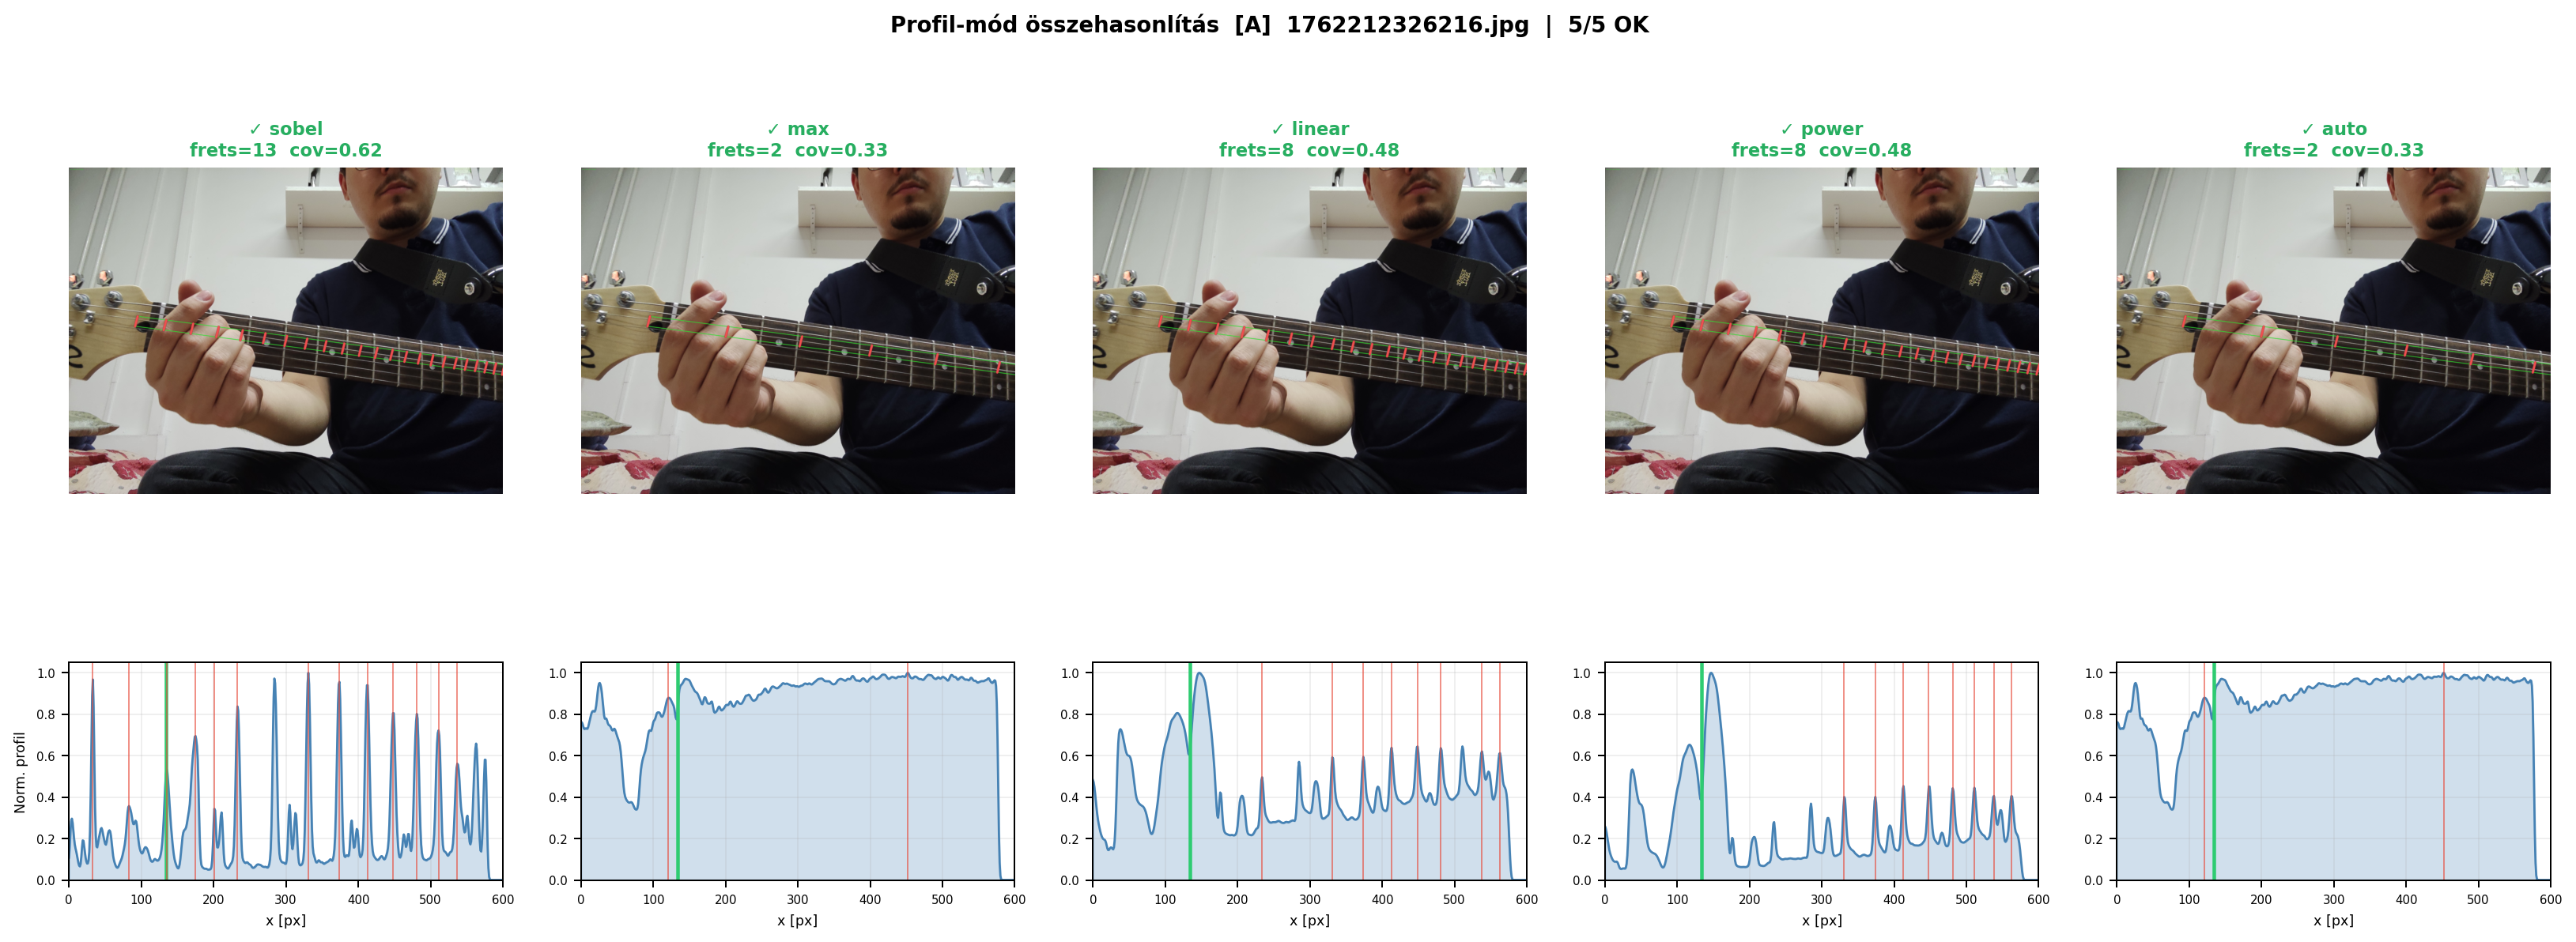

In [9]:
from src.viz import PipelineVisualizer
import matplotlib.gridspec as gridspec

def compare_profiling_modes(img_key: str = None, modes=None):
    """Futtat több profiling módot ugyanazon a képen, majd egymás mellé rajzolja.

    Ha ``img_key`` None, a jelenlegi dropdown értékét veszi.
    ``modes`` alapból: ['sobel', 'max', 'linear', 'power', 'auto'].
    """
    if modes is None:
        modes = ["sobel", "max", "linear", "power", "auto"]
    if img_key is None:
        img_key = w_image_select.value

    img_row     = image_options[img_key]
    preprocessor = ImagePreprocessor(config={
        "clahe_enabled":        bool(w_clahe.value),
        "clahe_clip_limit":     2.0,
        "clahe_tile_grid_size": (8, 8),
        "blur_enabled":         bool(w_blur.value),
        "blur_ksize":           int(w_blur_ksize.value),
        "normalize_enabled":    bool(w_normalize.value),
        "normalize_method":     "minmax",
    })

    results = {}
    for mode in modes:
        det = IntensityFretDetector(mode=mode, peak_height=float(w_peak_height.value))
        r   = run_v14_pipeline(img_row, fret_detector=det, preprocessor=preprocessor)
        results[mode] = r
        cov   = (r.get("fit") or {}).get("coverage_ratio", 0.0)
        frets = r.get("fret_xs_filt", [])
        nut   = r.get("nut")
        print(f"  [{mode:6s}]  ok={r.get('ok',False)}  frets={len(frets)}  cov={cov:.3f}  "
              f"nut={'@'+str(int(nut['nut_x']))+'px' if nut else 'n/a'}")

    # ── Összehasonlítás ábra ──────────────────────────────────────────────────
    n     = len(modes)
    n_ok  = sum(1 for r in results.values() if r.get("ok"))
    with high_res_figure_context():
        fig   = plt.figure(figsize=(4.5 * n, 7))
        gs    = gridspec.GridSpec(2, n, height_ratios=[3, 1.5], hspace=0.35, wspace=0.18)

        cls   = next(iter(results.values())).get("class", "?")
        fig.suptitle(
            f"Profil-mód összehasonlítás  [{cls}]  {img_key.split(']')[1].split('(')[0].strip()}"
            f"  |  {n_ok}/{n} OK",
            fontsize=11, fontweight="bold",
        )

        viz = PipelineVisualizer()
        for col, (mode, r) in enumerate(results.items()):
            img_bgr = r.get("img")
            nut     = r.get("nut")
            frets   = r.get("fret_xs_filt", [])
            profile = r.get("intensity_profile")
            cov     = (r.get("fit") or {}).get("coverage_ratio", 0.0)
            ok_lbl  = "✓" if r.get("ok") else "✗"

            # Overlay kép
            ax_img = fig.add_subplot(gs[0, col])
            if img_bgr is not None and r.get("ok"):
                ax_img.imshow(viz.draw_fretboard_overlay(img_bgr, r)[:, :, ::-1])
            elif img_bgr is not None:
                ax_img.imshow(img_bgr[:, :, ::-1])
            ax_img.set_title(
                f"{ok_lbl} {mode}\nfrets={len(frets)}  cov={cov:.2f}",
                fontsize=9, fontweight="bold",
                color=("#27ae60" if r.get("ok") else "#c0392b"),
            )
            ax_img.axis("off")

            # Profil
            ax_p = fig.add_subplot(gs[1, col])
            if profile is not None:
                xs = np.arange(len(profile))
                ax_p.fill_between(xs, profile, alpha=0.25, color="steelblue")
                ax_p.plot(xs, profile, color="steelblue", lw=1.1)
                if nut is not None:
                    ax_p.axvline(nut["nut_x"], color="#2ecc71", lw=1.8)
                for fx in frets:
                    ax_p.axvline(fx, color="#e74c3c", lw=0.7, alpha=0.7)
                ax_p.set_xlim(0, len(profile))
                ax_p.set_ylim(0, 1.05)
            else:
                ax_p.text(0.5, 0.5, "n/a", ha="center", va="center",
                          transform=ax_p.transAxes, color="gray")
            ax_p.grid(alpha=0.2)
            ax_p.tick_params(labelsize=6)
            ax_p.set_xlabel("x [px]", fontsize=7)
            if col == 0:
                ax_p.set_ylabel("Norm. profil", fontsize=7)

        plt.tight_layout()
        plt.show()


 # Futtatás:
compare_profiling_modes()